In [ ]:
import shap
import pickle

In [ ]:
# Calculate SHAP
explainer = shap.TreeExplainer(tuned_model)

In [ ]:
shap_values = explainer.shap_values(X_train)
shap_test_values = explainer.shap_values(X_test)

In [ ]:
# Define paths for saving
explainer_path = "../PCSC2025/explainers/explainer.pkl"
shap_values_train_path = "../PCSC2025/explainers/shap_values_train.pkl"
shap_values_test_path = "../PCSC2025/explainers/shap_values_test.pkl"

In [ ]:
# Save the explainer
with open(explainer_path, "wb") as f:
    pickle.dump(explainer, f)

# Save the SHAP values for training and test data
with open(shap_values_train_path, "wb") as f:
    pickle.dump(shap_values, f)

with open(shap_values_test_path, "wb") as f:
    pickle.dump(shap_test_values, f)

In [ ]:
# Load the explainer
with open(explainer_path, "rb") as f:
    explainer = pickle.load(f)

# Load the SHAP values for training and test data
with open(shap_values_train_path, "rb") as f:
    shap_values = pickle.load(f)

with open(shap_values_test_path, "rb") as f:
    shap_test_values = pickle.load(f)


In [ ]:
# Creating features list
features_list = dataset_encoded.drop(columns=['6_UCLA_total']).columns.tolist()
features_list

In [ ]:
# specifying class names
ucla_class_mapping = {
    1: 'Minimal loneliness',
    2: 'Low',
    3: 'Moderate',
    4: 'Moderately high',
    5: 'High'
}
class_names = [ucla_class_mapping[i] for i in sorted(ucla_class_mapping.keys())]

print(class_names)

In [ ]:
# Plot SHAP values for each class without manually specifying `n`
for i, class_name in enumerate(class_names):
    print(f"SHAP summary plot for class: {class_name}")
    shap.summary_plot(shap_values[:, :, i], X_train, feature_names=features_list, plot_type="bar")

In [ ]:
# Feature Effects
for i, class_name in enumerate(class_names):
    print(f"SHAP summary plot for class: {class_name}")
    shap.summary_plot(shap_values[:, :, i], X_train, feature_names=features_list)

In [ ]:
# Dependence
print('Interaction values')
shap_interaction_values = explainer.shap_interaction_values(X_test)
print(shap_interaction_values)

In [62]:
# Define a path for the interaction values
shap_interaction_values_test_path = "../PCSC2025/explainers/shap_interaction_values_test.pkl"

In [63]:
# Save the SHAP interaction values for the test data
with open(shap_interaction_values_test_path, "wb") as f:
    pickle.dump(shap_interaction_values, f)

In [64]:
# Load the SHAP interaction values for the test data
with open(shap_interaction_values_test_path, "rb") as f:
    shap_interaction_values = pickle.load(f)

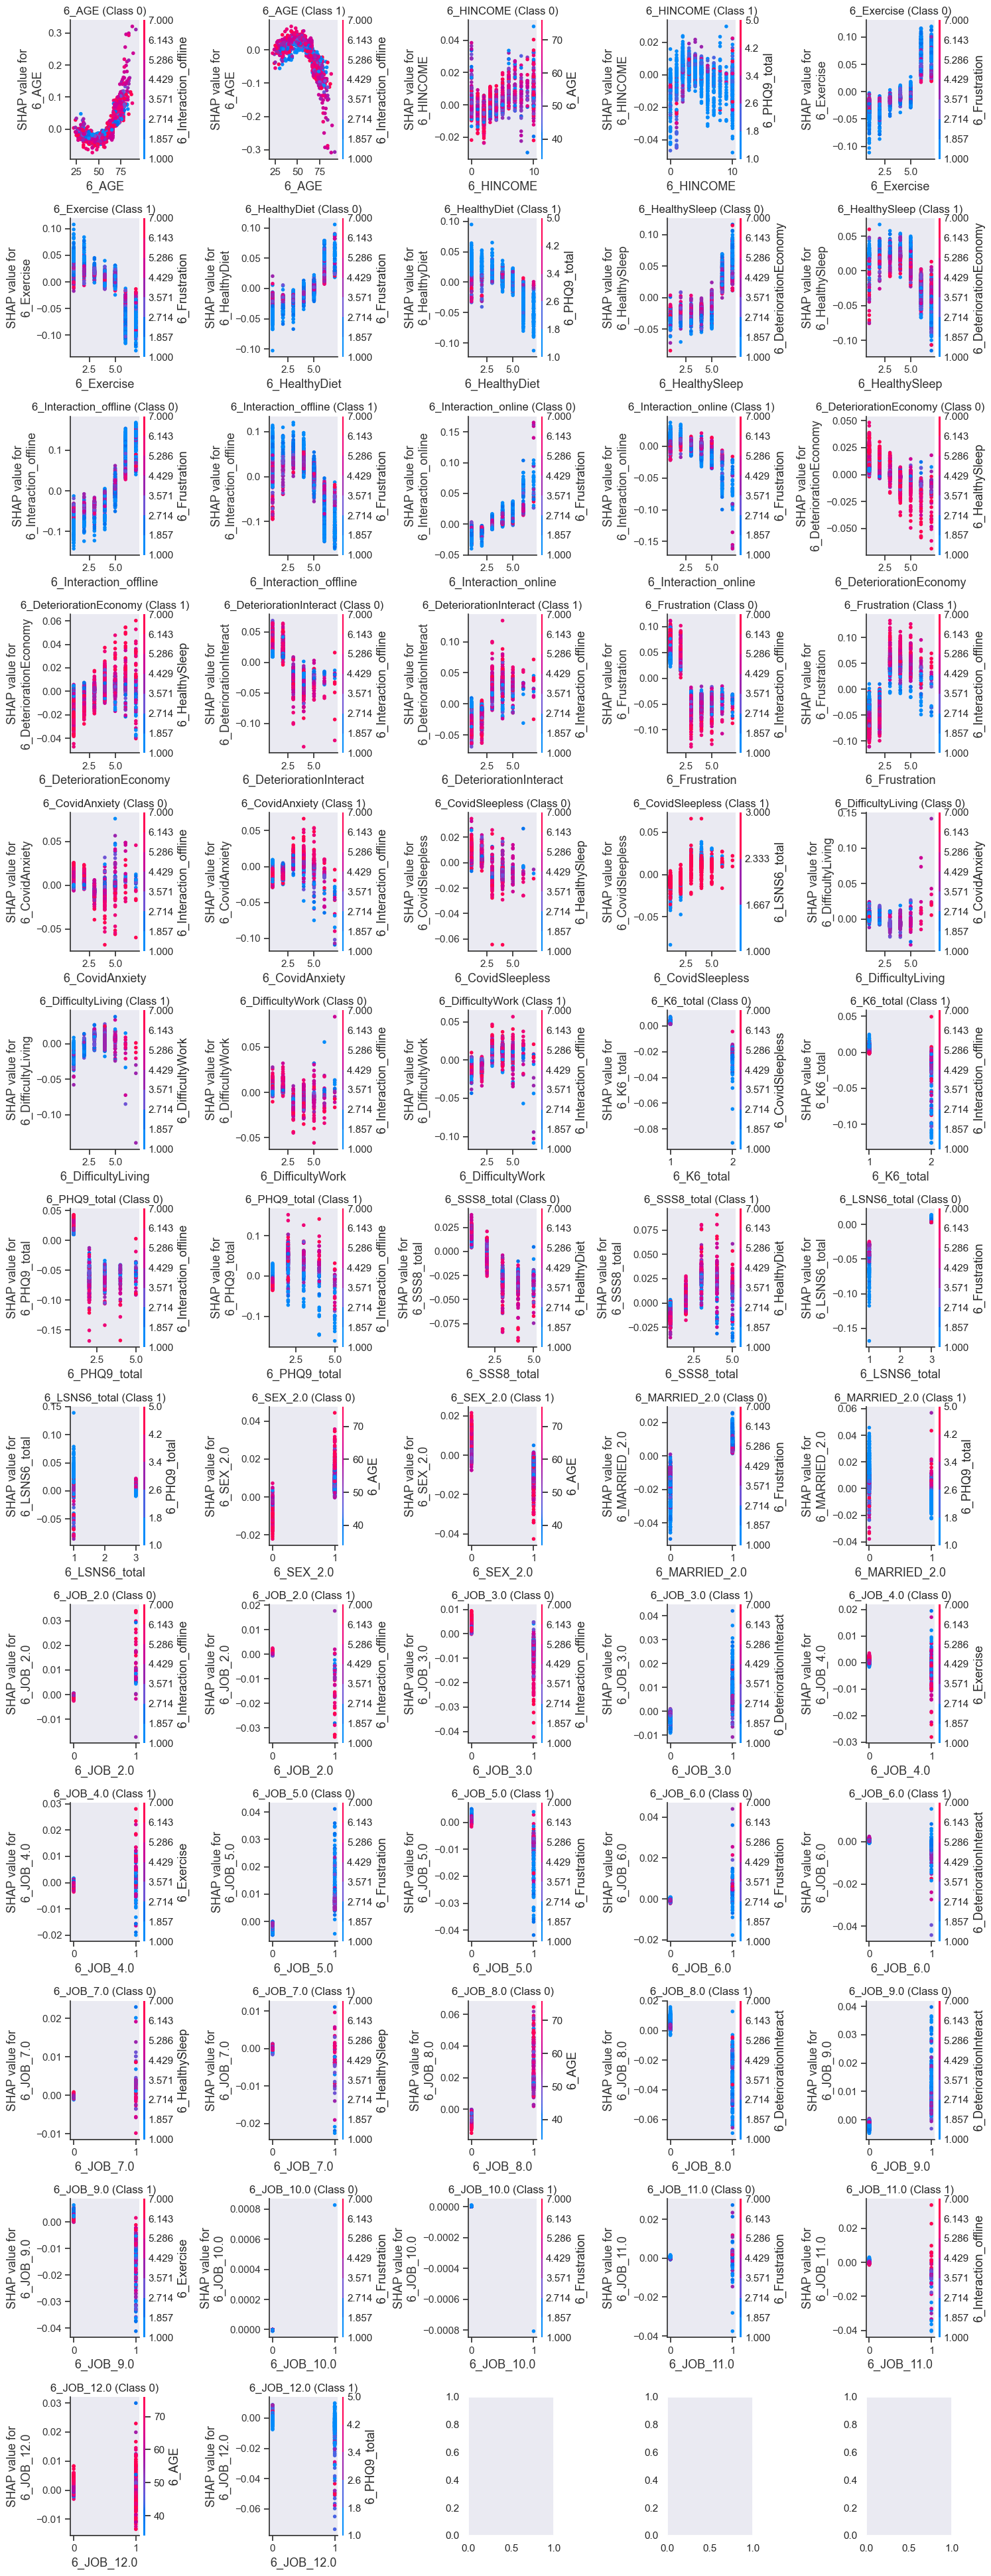

In [65]:
# Define number of rows and columns for the grid
n_features = len(features_list)
n_cols = len(class_names)
n_rows = (n_features * 2 + n_cols - 1) // n_cols  # 2 plots per feature (one for each class)

# Set up the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()  # Flatten to make indexing easier

# Loop over features to plot both classes
for idx, ft in enumerate(features_list):
    # Plot dependence for the first class
    shap.dependence_plot(
        ft, shap_values[:, :, 0], X_train, ax=axes[idx * 2], show=False
    )
    axes[idx * 2].set_title(f"{ft} (Class 0)")

    # Plot dependence for the second class
    shap.dependence_plot(
        ft, shap_values[:, :, 1], X_train, ax=axes[idx * 2 + 1], show=False
    )
    axes[idx * 2 + 1].set_title(f"{ft} (Class 1)")

# Adjust layout and display
plt.tight_layout()
plt.show()


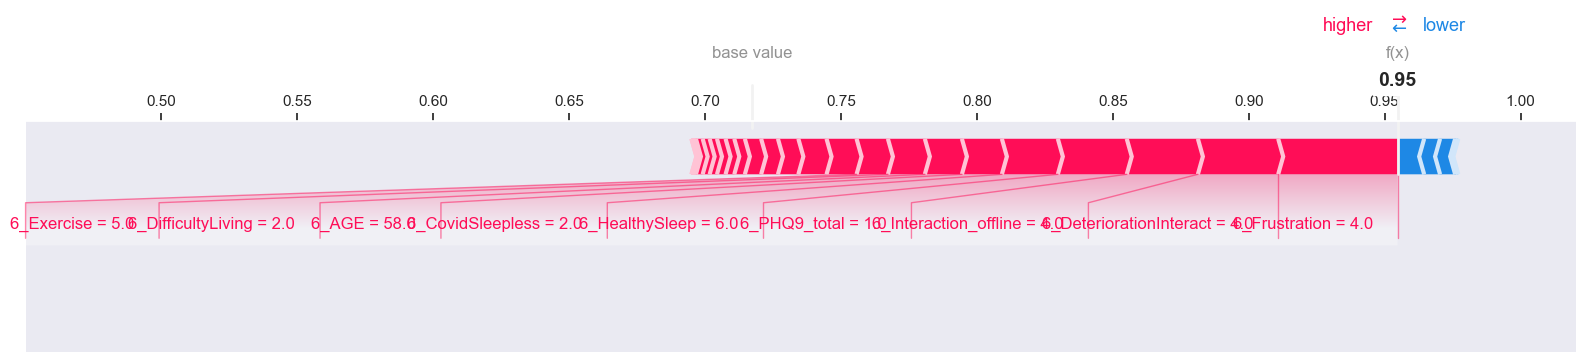

Sample: 6_AGE                       59.0
6_HINCOME                    1.0
6_Exercise                   4.0
6_HealthyDiet                4.0
6_HealthySleep               4.0
6_Interaction_offline        4.0
6_Interaction_online         4.0
6_DeteriorationEconomy       4.0
6_DeteriorationInteract      4.0
6_Frustration                4.0
6_CovidAnxiety               4.0
6_CovidSleepless             4.0
6_DifficultyLiving           4.0
6_DifficultyWork             4.0
6_K6_total                     1
6_PHQ9_total                   3
6_SSS8_total                   2
6_LSNS6_total                  3
6_SEX_2.0                   True
6_MARRIED_2.0              False
6_JOB_2.0                  False
6_JOB_3.0                  False
6_JOB_4.0                  False
6_JOB_5.0                  False
6_JOB_6.0                  False
6_JOB_7.0                  False
6_JOB_8.0                  False
6_JOB_9.0                   True
6_JOB_10.0                 False
6_JOB_11.0                 False
6_

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [66]:
# Additive Force
# Set sample index
i = 0  # Sample index

# Plot the force plot for the i-th sample and the second class
shap.force_plot(
    explainer.expected_value[1],  # Expected value for the second class
    shap_values[i, :, 1],         # SHAP values for the i-th sample, second class
    X_test.iloc[i],                # Features of the i-th sample
    feature_names=features_list,
    matplotlib=True
)

# Print sample details and SHAP values
print("Sample:", X_train.iloc[i])
print("\nSHAP Expected value for second class: %.2f" % explainer.expected_value[1])
print("Actual value: %.2f" % y_train.iloc[i])

# Extract the predicted value safely
predicted_value = tuned_model.predict(pd.DataFrame(X_train.iloc[i]).T)[0]  # Extract the first element
print("Predicted value: %.2f" % predicted_value)


# Local bar plot
